# 05 — Regime map: when does distribution win?

**Setup:** continuous 12-lead monitoring with the on-body export policy. Every orchestrator chiplet has the same SRAM cap S. The analysis window T sets the memory needed per lead, M_lead = T·fs·b ≈ T kB (at 500 S/s and 16 b). A lossless buffer-compression ratio r divides that.

**For each (S, T) cell the model picks the lowest-power architecture from:**
* centralized
* m = 4 with n = all, 8, 4, 2 or 1 nodes per SoC area

It reports which architecture wins and what it costs.

A partial-fit band is also predicted: if nothing fits fully but a one-lead head fits (M_base + T/r ≤ S), the finest architecture analyses part of the capture on-body and still wins.

**Closed-form prediction (A-11).** An orchestrator holding L independent leads fits if M_base + L·T/r ≤ S. Each architecture has a largest load per head, L_max (8 for centralized, down to 2 for m = 4, n = 1). The predicted winner is the architecture with the **fewest SoCs whose L_max fits**. If nothing fits, every design streams, and centralized wins because it carries the least overhead.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geometry as geo, power as pw
pd.set_option('display.width', 200)
p0 = pw.P()
g = geo.Garment(C=p0['torso_circ'], H=p0['torso_height'], Cs=p0['sleeve_circ'], Ls=p0['sleeve_len'])
sites = geo.build_layout(g, 'ML', int(p0['spares_per_site']))
D = geo.dist_matrix(g, sites); hub = geo.central_hub(g, sites); N = len(sites)
INK, MUTED = '#1f1f1e', '#6b6a64'
FLOOR = 10e-6
ARCH = [(N, N, 'centralized'), (4, N, 'm=4, 1 SoC'), (4, 8, 'm=4, n=8'), (4, 4, 'm=4, n=4'), (4, 2, 'm=4, n=2'), (4, 1, 'm=4, n=1')]
PT = {(m, n): geo.build_point(g, sites, D, m, n, 'mesh', 'mesh', hub) for m, n, _ in ARCH}
def P(**kw): return pw.P(export='onbody', schedule='cont12L', **kw)
def power(a, **kw): return pw.average_power(sites, D, PT[a], P(**kw), 'spec', FLOOR)['total'] * 1e6

## Largest analysis load per head, by architecture

In [2]:
info = []
for m, n, lbl in ARCH:
    L = pw.mode_load(sites, D, PT[(m, n)], '12L', P())
    lmax = max(int(round((v - p0['analysis_mem_base_kB']) / p0['analysis_mem_kB_lead'])) for v in L.head_mem_kB.values())
    info.append(dict(architecture=lbl, SoCs=PT[(m, n)].n_areas, heads_with_12L_leads=len(L.head_mem_kB), L_max=lmax))
INFO = pd.DataFrame(info).set_index('architecture'); INFO

,SoCs,heads_with_12L_leads,L_max
architecture,,,
centralized,1,1,8
"m=4, 1 SoC",1,1,8
"m=4, n=8",3,2,6
"m=4, n=4",5,3,4
"m=4, n=2",10,4,3
"m=4, n=1",19,6,2


## Sweep and closed-form check

In [3]:
Ts = [1, 2, 3, 4, 5, 7, 10, 14, 20, 30]
Ss = [8, 12, 16, 24, 32, 48, 64, 96, 128, 192, 256]
labels = [a[2] for a in ARCH]
def predicted(T, S, r):
    fits = [lbl for lbl in labels if p0['analysis_mem_base_kB'] + INFO.loc[lbl, 'L_max'] * T / r <= S]
    if not fits:
        # partial fit: heads holding a single lead still analyse on-body; the finest architecture gains most
        if p0['analysis_mem_base_kB'] + 1 * T / r <= S:
            return 'm=4, n=1'
        return 'none fit (centralized streams)'
    return min(fits, key=lambda l: INFO.loc[l, 'SoCs'])
res = {}
for r in [1.0, 2.5]:
    rows = []
    for T in Ts:
        for S in Ss:
            vals = {a[2]: power((a[0], a[1]), sram_cap_kB=S, analysis_mem_kB_lead=T, buf_ratio=r) for a in ARCH}
            win = min(vals, key=vals.get)
            Lw = pw.mode_load(sites, D, PT[[a for a in ARCH if a[2] == win][0][:2]], '12L', P(sram_cap_kB=S, analysis_mem_kB_lead=T, buf_ratio=r))
            win_lbl = win if Lw.onbody_frac > 0 else 'none fit (centralized streams)'
            rows.append(dict(T_s=T, S_kB=S, winner=win_lbl, power_uW=vals[win], predicted=predicted(T, S, r),
                             centralized_uW=vals['centralized']))
    res[r] = pd.DataFrame(rows)
    agree = (res[r].winner == res[r].predicted).mean()
    print(f"buffer ratio {r}: closed-form predicts the winner in {agree*100:.0f}% of {len(rows)} cells")
pd.concat(res, names=['buf_ratio']).to_csv('regime_map.csv')
mis = pd.concat([res[r][res[r].winner != res[r].predicted].assign(buf_ratio=r) for r in res])
mis

buffer ratio 1.0: closed-form predicts the winner in 100% of 110 cells


buffer ratio 2.5: closed-form predicts the winner in 100% of 110 cells


,T_s,S_kB,winner,power_uW,predicted,centralized_uW,buf_ratio


## The regime map

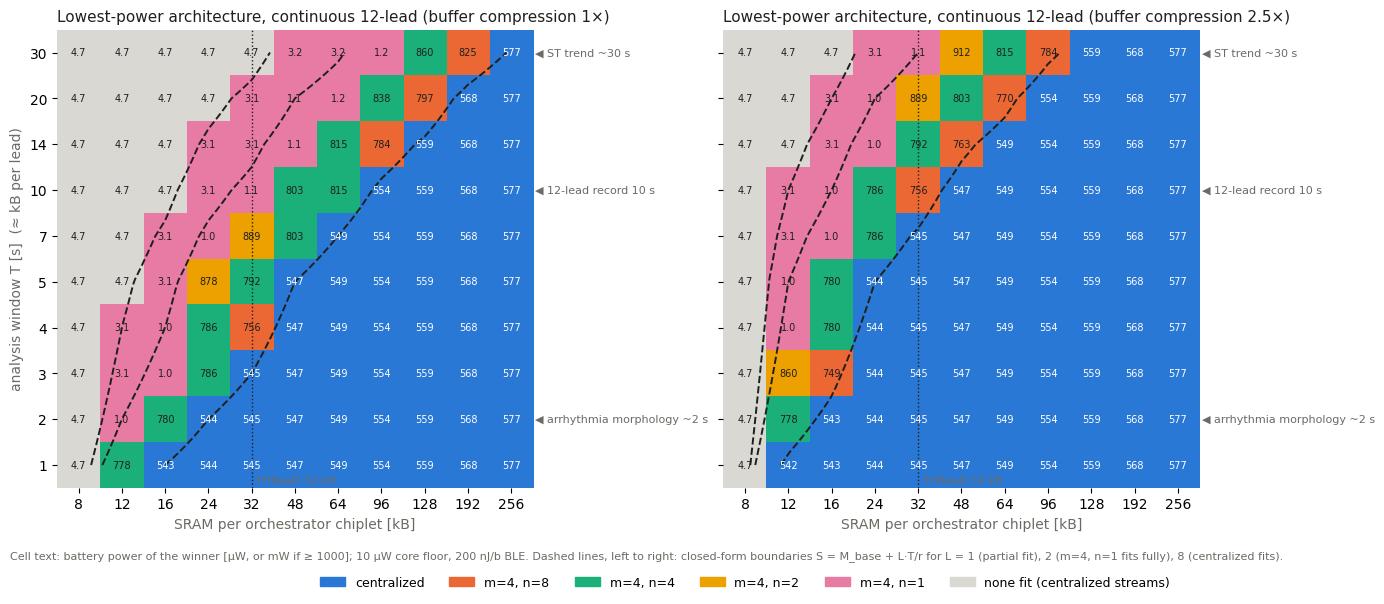

In [4]:
CATS = ['centralized', 'm=4, n=8', 'm=4, n=4', 'm=4, n=2', 'm=4, n=1', 'm=4, 1 SoC', 'none fit (centralized streams)']
COL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#4a3aa7', '#d9d8d2']
cmap = ListedColormap(COL)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, r in zip(axes, [1.0, 2.5]):
    R = res[r]
    Z = np.array([[CATS.index(R[(R.T_s == T) & (R.S_kB == S)].winner.values[0]) for S in Ss] for T in Ts])
    PW = np.array([[R[(R.T_s == T) & (R.S_kB == S)].power_uW.values[0] for S in Ss] for T in Ts])
    ax.imshow(Z, cmap=cmap, vmin=-0.5, vmax=len(CATS) - 0.5, origin='lower', aspect='auto')
    for i in range(len(Ts)):
        for j in range(len(Ss)):
            ax.text(j, i, f"{PW[i, j]/1000:.1f}" if PW[i, j] >= 1000 else f"{PW[i, j]:.0f}", ha='center', va='center',
                    fontsize=7, color='white' if Z[i, j] in (0, 5) else INK)
    # closed-form boundaries S = M_base + L*T/r, drawn in index coordinates
    sx = np.interp(np.log2(np.array(Ss, float)), np.log2(np.array(Ss, float)), np.arange(len(Ss)))
    for L, lbl in [(8, 'L=8: centralized fits'), (2, 'L=2: m=4, n=1 fully fits'), (1, 'L=1: partial fit')]:
        Tline = np.linspace(Ts[0], Ts[-1], 200)
        Sline = p0['analysis_mem_base_kB'] + L * Tline / r
        ok = (Sline >= Ss[0]) & (Sline <= Ss[-1])
        xs = np.interp(np.log2(Sline[ok]), np.log2(np.array(Ss, float)), np.arange(len(Ss)))
        ys = np.interp(Tline[ok], np.array(Ts, float), np.arange(len(Ts)))
        ax.plot(xs, ys, color=INK, lw=1.4, ls='--')
    ax.axvline(Ss.index(32), color=INK, lw=1, ls=':'); ax.text(Ss.index(32) + 0.1, -0.4, 'THReaD 32 kB', fontsize=8, color=MUTED)
    for T, lbl in [(2, 'arrhythmia morphology ~2 s'), (10, '12-lead record 10 s'), (30, 'ST trend ~30 s')]:
        ax.text(len(Ss) - 0.45, Ts.index(T), '◀ ' + lbl, fontsize=8, color=MUTED, va='center')
    ax.set_xticks(range(len(Ss)), Ss); ax.set_yticks(range(len(Ts)), Ts)
    ax.set_xlabel('SRAM per orchestrator chiplet [kB]', color=MUTED)
    ax.set_title(f'Lowest-power architecture, continuous 12-lead (buffer compression {r:g}×)', loc='left', fontsize=11, color=INK)
    for s_ in ax.spines.values(): s_.set_visible(False)
axes[0].set_ylabel('analysis window T [s]  (≈ kB per lead)', color=MUTED)
present = [i for i, c in enumerate(CATS) if any((res[r].winner == c).any() for r in res)]
handles = [plt.Rectangle((0, 0), 1, 1, color=COL[i]) for i in present]
fig.legend(handles, [CATS[i] for i in present], frameon=False, fontsize=9, ncol=7, loc='lower center', bbox_to_anchor=(0.5, -0.01))
fig.text(0.01, 0.06, 'Cell text: battery power of the winner [µW, or mW if ≥ 1000]; 10 µW core floor, 200 nJ/b BLE. Dashed lines, left to right: closed-form boundaries S = M_base + L·T/r for L = 1 (partial fit), 2 (m=4, n=1 fits fully), 8 (centralized fits).', fontsize=8, color=MUTED)
plt.tight_layout(rect=(0, 0.08, 0.93, 1)); plt.savefig('regime_map.png', dpi=160, bbox_inches='tight'); plt.show()

## How much power distribution is worth when it is the only option that fits

In [5]:
rows = []
for T in [5, 10, 20]:
    for S in [16, 32, 64]:
        R = res[1.0]; row = R[(R.T_s == T) & (R.S_kB == S)].iloc[0]
        rows.append(dict(T_s=T, S_kB=S, winner=row.winner, winner_uW=round(row.power_uW), centralized_uW=round(row.centralized_uW),
                         saving=f"{row.centralized_uW / row.power_uW:.1f}x"))
pd.DataFrame(rows)

,T_s,S_kB,winner,winner_uW,centralized_uW,saving
0,5,16,"m=4, n=1",3082,4710,1.5x
1,5,32,"m=4, n=4",792,4712,6.0x
2,5,64,centralized,549,549,1.0x
3,10,16,none fit (centralized streams),4710,4710,1.0x
4,10,32,"m=4, n=1",1070,4712,4.4x
5,10,64,"m=4, n=4",815,4717,5.8x
6,20,16,none fit (centralized streams),4710,4710,1.0x
7,20,32,"m=4, n=1",3126,4712,1.5x
8,20,64,"m=4, n=1",1157,4717,4.1x


## The breakeven inequality (A-11)

When centralized doesn't fit but a distributed design does, distribution wins if

  (n_SoC − 1) · (P_floor + P_leak·S) / η  <  E_bit · (R_stream − R_onbody) / η

Below are the two sides for continuous 12-lead.

In [6]:
R_stream = 8 * 500 * 16 / p0['compress_ratio']                                   # bps, compressed 8-lead stream
R_onbody = (12 * p0['feat_bits_lead_12L'] + p0['p_abnormal'] * 8 * 500 * 16 * 10 / p0['compress_ratio']) / 10
dP_tx = p0['E_tx_ble'] * 1e-9 * (R_stream - R_onbody) / p0['eta_pmu'] * 1e6
per_soc = (FLOOR * 1e6 + p0['sram_leak_uW_kB'] * 32) / p0['eta_pmu']
print(f"R_stream = {R_stream/1e3:.1f} kbps, R_onbody = {R_onbody/1e3:.2f} kbps")
print(f"TX saving from on-body analysis: {dP_tx:.0f} uW at the battery (200 nJ/b)")
print(f"cost per extra SoC: {per_soc:.1f} uW  ->  breakeven at {dP_tx/per_soc:.0f} extra SoCs")
for etx in [50, 200]:
    print(f"  E_bit = {etx} nJ/b: breakeven = {etx*1e-9*(R_stream-R_onbody)/p0['eta_pmu']*1e6/per_soc:.0f} extra SoCs")

R_stream = 16.0 kbps, R_onbody = 1.41 kbps
TX saving from on-body analysis: 4167 uW at the battery (200 nJ/b)
cost per extra SoC: 18.9 uW  ->  breakeven at 221 extra SoCs
  E_bit = 50 nJ/b: breakeven = 55 extra SoCs
  E_bit = 200 nJ/b: breakeven = 221 extra SoCs


## Findings

1. **The closed form predicts the winner in 100% of 220 cells** (two buffer ratios × 110 cells). The rule is the fewest-SoC architecture whose largest per-head load L_max satisfies M_base + L_max·T/r ≤ S, with a partial-fit band down to L = 1. So the regime map is not a quirk of this layout: it follows from three numbers per architecture (SoC count, L_max, and per-SoC cost).
2. **Three regimes for continuous 12-lead:**
   * **Centralized** wins above S = M_base + 8T/r. It costs about 545–577 µW (200 nJ/b BLE).
   * **Distributed** wins between the L = 1 and L = 8 lines, costing about 0.75–1.2 mW fully fitted and about 3 mW partially fitted. That is **1.5–6× below** a centralized design that has to stream (4.7 mW).
   * **Nothing fits** below S = M_base + T/r: everyone streams and centralized wins on overhead.
3. **At THReaD-class 32 kB with lossless buffers (r = 1):** distribution wins for every window from 4 s to 20 s. That covers the standard 10 s 12-lead record, where m = 4, n = 1 needs 1.07 mW against 4.7 mW. Centralized wins only for very short windows (≤ 3 s).
4. **Lossless buffer compression shifts every boundary by r.** At 2.5×, centralized fits a 10 s window at 40 kB instead of 88 kB. Distribution still wins at 32 kB for windows of 10 s and longer, so the effect survives the strongest objection, but its region shrinks.
5. **Distribution essentially always wins when it is the only option that fits.** On-body analysis saves about 4.2 mW of TX at 200 nJ/b (16 kbps compressed vs. 1.4 kbps on-body), while each extra SoC costs about 19 µW. Breakeven is about 220 extra SoCs at 200 nJ/b, or about 55 at 50 nJ/b. So the regime boundaries are set by memory, not by the power trade.
6. **Inside the distributed region, the fewest SoCs that fit is best.** n = 8 beats n = 4 beats n = 1 whenever each fits, because per-SoC floors add up. The chiplet spec trade is therefore SRAM per chiplet against the number of orchestrators.
7. **What would move the map:**
   * the SRAM leakage per kB (unverified), which sets the slow rise to the right;
   * the per-SoC core floor;
   * BLE energy, which scales the absolute numbers but barely moves the boundaries.
